## Loading Data
Loading data from the data preprocessing step

In [3]:
from pathlib import Path
from pyspark.sql import SparkSession

import os
import sys

python_exe = sys.executable
os.environ["PYSPARK_PYTHON"] = python_exe
os.environ["PYSPARK_DRIVER_PYTHON"] = python_exe

spark = (
    SparkSession.builder
    .appName("EEG_Schizoprenia")
    .master("local[2]")                  # avoid local[*] for heavy tuning
    .config("spark.pyspark.python", python_exe)
    .config("spark.pyspark.driver.python", python_exe)
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.memory", "6g") # raise this
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

sc = spark.sparkContext
print("Spark started:", spark.version)
print("Python:", sc.pythonExec)

Spark started: 4.0.0
Python: C:\Users\Joy Anne\anaconda3\envs\DSAI4202\python.exe


In [4]:
from pathlib import Path

from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.classification import LinearSVC

project_root = Path("").resolve()

input_path = project_root / "data" / "processed" / "pca_final_modeling_table"

df = spark.read.parquet(str(input_path))

## Splitting the Dataframe to Train and Test

To avoid data leakage when training the model, the data is split by subjects/participants. Although the subject is not part of the feature column, we still separate the train and test sets to ensure there is no overlap of subjects. In other words, no participant appears in both the training and testing sets

In [5]:
from pyspark.sql import functions as F

subject_df = df.groupBy("subject").agg(F.first("label").alias("label"))

# split by subjects to avoid data leakage
train_subjects = subject_df.sampleBy("label", fractions={0.0: 0.8, 1.0: 0.8}, seed=4202)
train_df = df.join(train_subjects.select("subject"), on="subject", how="inner")

test_subjects = subject_df.join(train_subjects.select("subject"), on="subject", how="left_anti") # not in train_subjects
test_df = df.join(test_subjects.select("subject"), on="subject", how="inner")

In [6]:
train_subject_list = [int(row["subject"]) for row in train_subjects.orderBy("subject").select("subject").collect()]
test_subject_list = [int(row["subject"]) for row in test_subjects.orderBy("subject").select("subject").collect()]

print("Train Subjects:", train_subject_list)
print("Test Subjects:", test_subject_list)

# confirm no overlap of subjects
print("Number of participant that exist in both train and test:", len(set(train_subject_list) & set(test_subject_list)))


Train Subjects: [1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 32, 33, 35, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 75, 76, 77, 78, 80, 81]
Test Subjects: [4, 9, 16, 19, 26, 31, 34, 36, 40, 45, 46, 51, 74, 79]
Number of participant that exist in both train and test: 0


## Model Training

This is a binary classification task, we selected classifiers accordingly, using models from the PySpark ml.classification module. Because the reduced dataset is small enough and we can run on local GPUs, we are not heavily constrained in model selection. We start with a baseline model using logistic regression, then move toward more complex models, up to a multilayer perceptron (MLP).


In [7]:
from pyspark.ml.classification import LogisticRegression

lrModel = (
    LogisticRegression(
        labelCol="label",
        featuresCol="pcaFeatures",
        elasticNetParam=0.5
    )
)

lrFitted = lrModel.fit(train_df)
lrPredictions = lrFitted.transform(test_df)

In [8]:
from pyspark.ml.classification import DecisionTreeClassifier

dtModel = (
    DecisionTreeClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        seed=4202
    )
)

dtFitted = dtModel.fit(train_df)
dtPredictions = dtFitted.transform(test_df)

In [12]:
from pyspark.ml.classification import RandomForestClassifier

rfModel = (
    RandomForestClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        seed=4202
    )
)

rfFitted = rfModel.fit(train_df)
rfPredictions = rfFitted.transform(test_df)

In [10]:
from pyspark.ml.classification import LinearSVC

svmModel = (
    LinearSVC(
        labelCol="label",
        featuresCol="pcaFeatures",
        maxIter=100,
        regParam=0.1
    )
)

svmFitted = svmModel.fit(train_df)
svmPredictions = svmFitted.transform(test_df)

In [11]:
from pyspark.ml.classification import NaiveBayes

nbModel = (
    NaiveBayes(
        labelCol="label",
        featuresCol="pcaFeatures",
        modelType="gaussian"   # cuz continuous
    )
)

nbFitted = nbModel.fit(train_df)
nbPredictions = nbFitted.transform(test_df)


In [12]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

input_size = len(train_df.select("pcaFeatures").first()[0])

mlpModel = (
    MultilayerPerceptronClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        # layers=[input_size, 512, 512, 126, 64, 2],
        layers=[input_size, 64, 32, 2], #simpler MLPC
        seed=4202,
        maxIter=100
    )
)

mlpFitted = mlpModel.fit(train_df)
mlpPredictions = mlpFitted.transform(test_df)

## Model Evaluation

The models are evaluated through a clinical lens. The dataset consists of Electroencephalography (EEG) data used as a diagnostic aid for predicting Schizophrenia in patients. The model is not intended to provide a definitive diagnosis, but rather to serve as supporting evidence for early screening and detection.

Within this context, missing a schizophrenia case (false negative) is the more consequential error, as it may lead to delayed treatment, worsening symptoms, and increased long-term risk. In contrast, a false positive may result in additional testing but can be ruled out through further clinical evaluation.

Accordingly, _the primary evaluation metric is recall_ (sensitivity), which measures the proportion of patients with schizophrenia who are correctly identified by the model. This focus ensures that potential cases are not overlooked, particularly in early-onset scenarios. To complement this, the area under the precision–recall curve (AUC-PR) is used to assess overall model performance, with emphasis on the model’s ability to correctly identify positive cases across different decision thresholds.

In [7]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_predictions(predictions, model = None):
    
    # AUC-ROC: only for binary classification
    binary_evaluator = BinaryClassificationEvaluator( labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    # Accuracy / Precision / Recall / F1
    multi_evaluator = MulticlassClassificationEvaluator( labelCol="label", predictionCol="prediction")
    
    metrics = {}

    if model:
        print(f"{model} Metrics:")
        metrics['model'] = model

    metrics["recall"] = multi_evaluator.setMetricName("weightedRecall").evaluate(predictions)
    print(f"- Recall: {metrics['recall']:.4f} (Primary Metric)")

    metrics["auc_pr"] = binary_evaluator.setMetricName("areaUnderPR").evaluate(predictions)
    print(f"- Area Under PR: {metrics['auc_pr']:.4f}")

    metrics["auc_roc"] = binary_evaluator.evaluate(predictions)
    print(f"- Area Under ROC: {metrics['auc_roc']:.4f}")

    metrics["f1"] = multi_evaluator.setMetricName("f1").evaluate(predictions)
    print(f"- F1 Score: {metrics['f1']:.4f}")

    metrics["accuracy"] = multi_evaluator.setMetricName("accuracy").evaluate(predictions)
    print(f"- Accuracy: {metrics['accuracy']:.4f}")

    metrics["precision"] = multi_evaluator.setMetricName("weightedPrecision").evaluate(predictions)
    print(f"- Precision: {metrics['precision']:.4f}")


    print("")

    return metrics

In [14]:
lr_metrics = evaluate_predictions(lrPredictions, "LogisticRegression")
dt_metrics = evaluate_predictions(dtPredictions, "DecisionTreeClassifier")
rf_metrics = evaluate_predictions(rfPredictions, "RandomForestClassifier")
svm_metrics = evaluate_predictions(svmPredictions, "LinearSVC")
nb_metrics = evaluate_predictions(nbPredictions, "NaiveBayes")
mlp_metrics = evaluate_predictions(mlpPredictions, "MultilayerPerceptronClassifier")

LogisticRegression Metrics:
- Recall: 0.5880 (Primary Metric)
- Precision: 0.6509
- Area Under PR: 0.8400
- Area Under ROC: 0.8400
- F1 Score: 0.6071
- Accuracy: 0.5880

DecisionTreeClassifier Metrics:
- Recall: 0.5863 (Primary Metric)
- Precision: 0.6227
- Area Under PR: 0.7309
- Area Under ROC: 0.7309
- F1 Score: 0.6005
- Accuracy: 0.5863

RandomForestClassifier Metrics:
- Recall: 0.6918 (Primary Metric)
- Precision: 0.5931
- Area Under PR: 0.7929
- Area Under ROC: 0.7929
- F1 Score: 0.6099
- Accuracy: 0.6918

LinearSVC Metrics:
- Recall: 0.5503 (Primary Metric)
- Precision: 0.6001
- Area Under PR: 0.7823
- Area Under ROC: 0.7823
- F1 Score: 0.5687
- Accuracy: 0.5503

NaiveBayes Metrics:
- Recall: 0.5831 (Primary Metric)
- Precision: 0.7405
- Area Under PR: 0.5642
- Area Under ROC: 0.5642
- F1 Score: 0.5982
- Accuracy: 0.5831

MultilayerPerceptronClassifier Metrics:
- Recall: 0.5615 (Primary Metric)
- Precision: 0.6062
- Area Under PR: 0.7260
- Area Under ROC: 0.7260
- F1 Score: 0.57

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np

metrics_list = [
    lr_metrics,
    dt_metrics,
    rf_metrics,
    svm_metrics,
    nb_metrics,
    mlp_metrics
]

spark = SparkSession.builder.getOrCreate()

df_metrics = spark.createDataFrame(metrics_list)

df_metrics = df_metrics.select(
    "model", "recall", "auc_pr", "auc_roc", "f1", "accuracy", "precision"
).orderBy(col("recall").desc())

df_metrics.show(truncate=False)

+------------------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|model                         |recall            |precision         |auc_pr            |auc_roc           |f1                |accuracy          |
+------------------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|RandomForestClassifier        |0.6918301465110505|0.5931325107806102|0.7929060182346696|0.7929114071503668|0.6099343968305386|0.6918301465110505|
|LogisticRegression            |0.5880307921529675|0.6508703563824839|0.8399777423947298|0.8399661873881391|0.607062666518679 |0.5880307921529675|
|DecisionTreeClassifier        |0.586292525453191 |0.6226543706826487|0.73094539095366  |0.73094539095366  |0.6004758733068652|0.586292525453191 |
|NaiveBayes                    |0.5830643158678918|0.7404522323473804|0.5641855050072001|0.5641830798855224|0.59816727

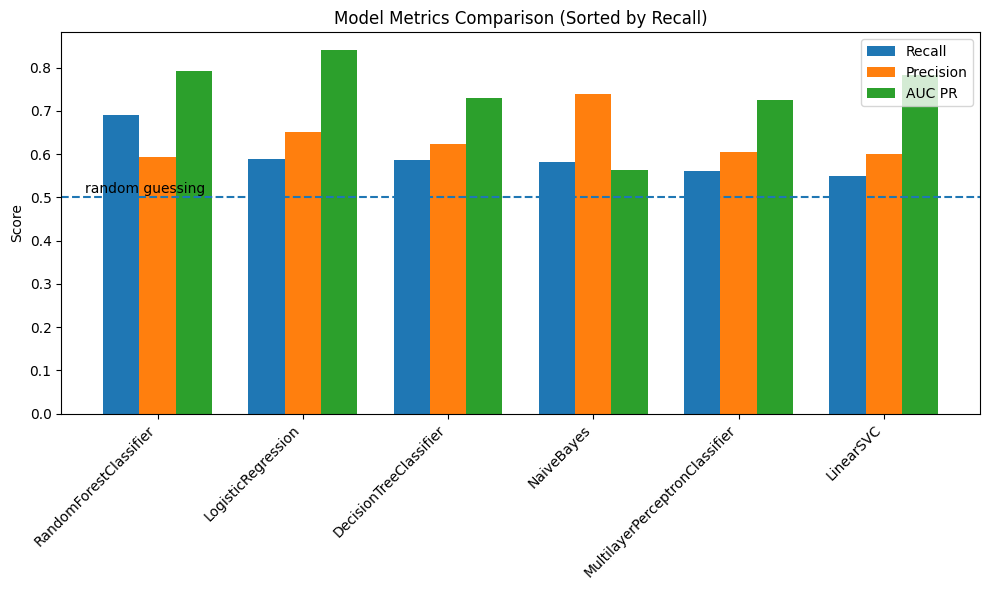

In [17]:
rows = df_metrics.select("model", "recall",  "auc_pr", "precision").collect()

models = [row["model"] for row in rows]
recall = [row["recall"] for row in rows]
precision = [row["precision"] for row in rows]
auc_pr = [row["auc_pr"] for row in rows]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, recall, width, label="Recall")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, auc_pr, width, label="AUC PR")

plt.axhline(0.5, linestyle="--")
plt.text(-0.5, 0.51, "random guessing")

plt.ylabel("Score")
plt.title("Model Metrics Comparison (Sorted by Recall)")
plt.xticks(x, models, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Based on the baseline experimental results, the Random Forest Classifier was selected for hyperparameter tuning because it produced the highest recall among all evaluated models. As recall was treated as the primary metric, this model was considered the most suitable candidate for further optimization.

Hyperparameter tuning was performed to improve the model's sensitivity while maintaining reasonable overall predictive performance. The parameters explored included the number of trees, maximum depth, and minimum instances per node, as these are key factors influencing the behavior and complexity of a Random Forest model.

Initial attempts to run full cross-validation resulted in Java heap memory failures in the local environment due to the computational cost of repeatedly training the model across multiple parameter combinations and folds. To address this limitation, a VectorSlicer was introduced to retain only the top PCA-derived features before classification, reducing the feature space and making the workflow lighter to execute on the local laptop. This adjustment also allowed the implementation to demonstrate the use of a Spark ML pipeline and cross-validation setup in a practical way, while remaining feasible within the available system resources.


In [10]:
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

rf_cv = RandomForestClassifier(
    labelCol="label",
    featuresCol="pcaFeatures",
    seed=4202
)

rf_pipeline = Pipeline(stages=[rf_cv])

rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf_cv.numTrees, [50, 100])
    .addGrid(rf_cv.maxDepth, [5, 10])
    .addGrid(rf_cv.minInstancesPerNode, [1, 2])
    .build()
)

rf_cv_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

rf_crossval = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=rf_cv_evaluator,
    numFolds=3,
    seed=4202
)

rf_cv_model = rf_crossval.fit(train_df)
rf_cv_predictions = rf_cv_model.transform(test_df)

rf_cv_metrics = evaluate_predictions(
    rf_cv_predictions,
    "RandomForestClassifier_CV"
)

best_rf_model = rf_cv_model.bestModel.stages[-1]
print("Best numTrees:", best_rf_model.getNumTrees)
print("Best maxDepth:", best_rf_model.getOrDefault("maxDepth"))
print("Best minInstancesPerNode:", best_rf_model.getOrDefault("minInstancesPerNode"))


RandomForestClassifier_CV Metrics:
- Recall: 0.5294 (Primary Metric)
- Area Under PR: 0.5771
- Area Under ROC: 0.5771
- F1 Score: 0.4972
- Accuracy: 0.5294
- Precision: 0.4702

Best numTrees: 100
Best maxDepth: 10
Best minInstancesPerNode: 1


In [9]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorSlicer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

positive_label = 1.0
top_k = 128

slicer = VectorSlicer(
    inputCol="pcaFeatures",
    outputCol="rfFeatures",
    indices=list(range(top_k))
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="rfFeatures",
    seed=4202,
    featureSubsetStrategy="sqrt"
)

rf_pipeline = Pipeline(stages=[slicer, rf])

rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 8])
    .addGrid(rf.minInstancesPerNode, [1, 2])
    .build()
)

# optimize recall for the positive class
rf_cv_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="recallByLabel",
    metricLabel=positive_label
)

rf_crossval = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=rf_cv_evaluator,
    numFolds=3
)

rf_cv_model = rf_crossval.fit(train_df)
rf_cv_predictions = rf_cv_model.transform(test_df)

rf_cv_metrics = evaluate_predictions(
    rf_cv_predictions,
    "Pipeline(VectorSlicer -> RandomForestCV)"
)

best_rf = rf_cv_model.bestModel.stages[-1]
print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getOrDefault("maxDepth"))
print("Best minInstancesPerNode:", best_rf.getOrDefault("minInstancesPerNode"))


Pipeline(VectorSlicer -> RandomForestCV) Metrics:
- Recall: 0.5539 (Primary Metric)
- Area Under PR: 0.6176
- Area Under ROC: 0.6176
- F1 Score: 0.5104
- Accuracy: 0.5539
- Precision: 0.4753

Best numTrees: 100
Best maxDepth: 5
Best minInstancesPerNode: 1


In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorSlicer
from pyspark.ml.classification import RandomForestClassifier

positive_label = 1.0
top_k = 128

slicer = VectorSlicer(
    inputCol="pcaFeatures",
    outputCol="rfFeatures",
    indices=list(range(top_k))
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="rfFeatures",
    seed=4202,
    featureSubsetStrategy="sqrt",
    numTrees=100,              # pick fixed values
    maxDepth=8,
    minInstancesPerNode=1
)

rf_pipeline = Pipeline(stages=[slicer, rf])

rf_model = rf_pipeline.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_metrics = evaluate_predictions(
    rf_predictions,
    "Pipeline(VectorSlicer -> RandomForest)"
)

trained_rf = rf_model.stages[-1]
print("numTrees:", trained_rf.getNumTrees)
print("maxDepth:", trained_rf.getOrDefault("maxDepth"))
print("minInstancesPerNode:", trained_rf.getOrDefault("minInstancesPerNode"))


Pipeline(VectorSlicer -> RandomForest) Metrics:
- Recall: 0.5230 (Primary Metric)
- Area Under PR: 0.6037
- Area Under ROC: 0.6037
- F1 Score: 0.4957
- Accuracy: 0.5230
- Precision: 0.4725

numTrees: 100
maxDepth: 8
minInstancesPerNode: 1


Cross-validation results show a recall of approximately 0.59, which is lower than the previously observed test recall. This discrepancy is likely influenced by several constraints in the experimental setup. First, the use of a 3-fold cross-validation scheme introduces higher variance in performance estimates compared to larger fold sizes. Second, dimensionality reduction through PCA to 128 features—applied due to memory limitations—may have removed informative signals, negatively affecting model performance.

## Error Analysis on Training and Test Sets

Error analysis was performed on both the training and test sets to better understand how the model behaves beyond overall evaluation metrics. Examining the training set helps identify whether the model has learned the patterns in the data effectively, while examining the test set shows how well those learned patterns generalize to unseen data. Comparing errors across both sets is useful for detecting issues such as overfitting, underfitting, class imbalance, or systematic misclassification. This provides a clearer interpretation of model performance and helps determine whether the model is reliable for the classification task.

In [ ]:
rf_train_predictions = rfFitted.transform(train_df)

rf_train_metrics = evaluate_predictions( rf_train_predictions, "RandomForestClassifier [Train]")
rf_metrics = evaluate_predictions(rfPredictions, "RandomForestClassifier [Test]")

RandomForestClassifier [Train] Metrics:
- Recall: 0.6824 (Primary Metric)
- Area Under PR: 0.8922
- Area Under ROC: 0.8922
- F1 Score: 0.6293
- Accuracy: 0.6824
- Precision: 0.7548

RandomForestClassifier [Test] Metrics:
- Recall: 0.6175 (Primary Metric)
- Area Under PR: 0.5985
- Area Under ROC: 0.5985
- F1 Score: 0.5412
- Accuracy: 0.6175
- Precision: 0.4838



The recall only decreased slightly (~0.07), indicating the model maintains its ability to identify positive cases. However, both ROC AUC and PR AUC dropped significantly (from ~0.89 to ~0.60), showing that the model’s generalization fails on unseen data. This suggests the model is **overfitting**, as it captures patterns in the training data that do not generalize well to the test set. The large drop in precision further indicates an increase in false positives during testing.

In [7]:
# spark.stop()